In [143]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

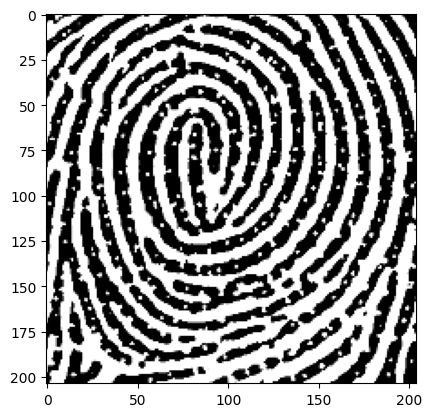

In [144]:
img = cv2.imread("../images/50_whorl.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.threshold(img, 127, 255, cv2.THRESH_OTSU + cv2.THRESH_BINARY)[1]

rescaled_dims = img.shape[0] * 0.4
img = cv2.resize(img, (int(img.shape[1] * 0.4), int(img.shape[0] * 0.4)))

H = img.shape[0]
W = img.shape[1]

plt.imshow(img, cmap='gray')

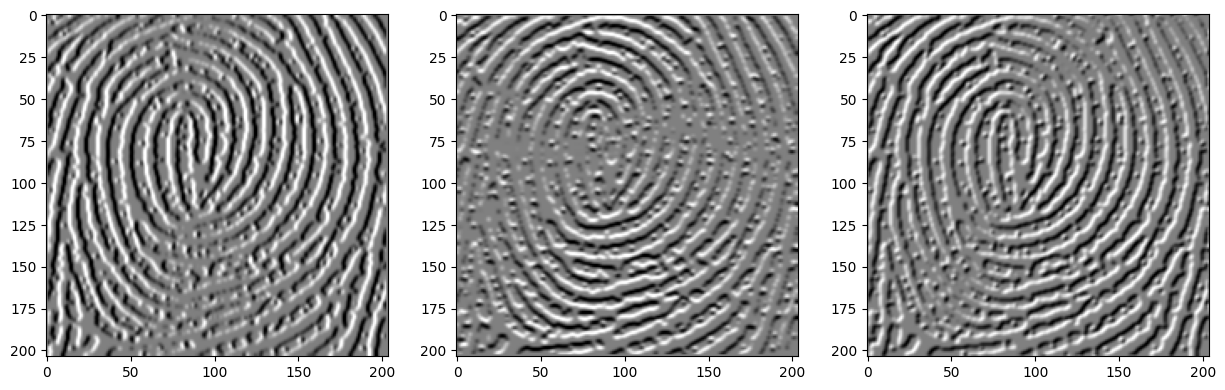

In [145]:
edge_horiz = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
edge_vert = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(edge_horiz, cmap='gray')

plt.subplot(1, 3, 2)
plt.imshow(edge_vert, cmap='gray')

plt.subplot(1, 3, 3)
plt.imshow(edge_horiz + edge_vert, cmap='gray')

In [146]:
I = cv2.GaussianBlur(img, (3, 3), 1.5)

J11 = cv2.boxFilter(edge_horiz * edge_horiz, cv2.CV_64F, (16, 16))
J22 = cv2.boxFilter(edge_vert * edge_vert, cv2.CV_64F, (16, 16))
J12 = cv2.boxFilter(edge_horiz * edge_vert, cv2.CV_64F, (16, 16))

theta = 0.5 * np.arctan2(2 * J12, J11 - J22)
theta

array([[ 1.35487092,  1.35487092,  1.35864881, ..., -0.52960491,
        -0.53580784, -0.53644769],
       [ 1.35487092,  1.35487092,  1.35864881, ..., -0.52960491,
        -0.53580784, -0.53644769],
       [ 1.28745604,  1.28745604,  1.31335134, ..., -0.53894675,
        -0.54546199, -0.5464405 ],
       ...,
       [ 0.36753788,  0.36753788,  0.36322931, ...,  0.10022519,
         0.12812119,  0.12343158],
       [ 0.44041712,  0.44041712,  0.43162743, ...,  0.10163974,
         0.13618338,  0.13231059],
       [ 0.44640978,  0.44640978,  0.43157762, ...,  0.10877485,
         0.14396898,  0.13945542]], shape=(204, 204))

In [147]:
coh = np.sqrt((J11 - J22) ** 2 + 4 * J12**2) / (J11 + J22 + 1e-8)

block = 16
f_map = np.full_like(I, np.nan, dtype=float)

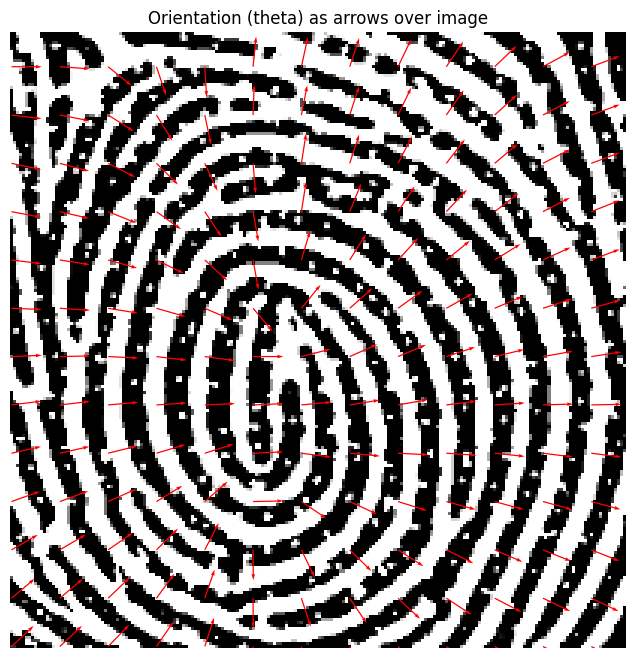

In [167]:
# Choose a stride equal to the block size to make arrows readable
stride = 16
ys = np.arange(0, theta.shape[0], stride)
xs = np.arange(0, theta.shape[1], stride)
X, Y = np.meshgrid(xs, ys)
# Sample the theta values at the grid points (rows, cols)
theta_sample = theta[Y, X]
# Compute arrow components (cos, sin) — these point along the orientation
U = np.cos(theta_sample)
V = np.sin(theta_sample)

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
# quiver expects X,Y in image coords (cols, rows) — so pass X and Y
plt.quiver(X, Y, U, V, color="red", angles="xy", scale_units="xy", scale=0.1, width=0.002)
plt.gca().invert_yaxis()
plt.title('Orientation (theta) as arrows over image')
plt.axis('off')
plt.show()

In [149]:
import matplotlib.pyplot as plt


def quiver_theta(theta, img=None, stride=16, scale=1.0, width=0.002, color="r", highlight_blocks=False):
    H, W = theta.shape
    nb_x, nb_y = W // stride, H // stride

    ys = np.arange(0, H, stride)
    xs = np.arange(0, W, stride)
    X, Y = np.meshgrid(xs, ys)

    th_s = theta[Y, X]
    # Orientation is π-periodic → use 2θ to get a direction vector
    U = np.cos(th_s)
    V = np.sin(th_s)

    plt.figure(figsize=(8, 8))
    if img is not None:
        plt.imshow(img, cmap="gray")
        
    plt.quiver(
        X,
        Y,
        U,
        V,
        color=color,
        angles="xy",
        scale_units="xy",
        scale=scale,
        width=width,
        headaxislength=0,
        headlength=0,
        headwidth=0,
    )

    # Highlight the blocks with cyan squares
    if highlight_blocks:
        for i in range(nb_y):
            for j in range(nb_x):
                rect = plt.Rectangle(
                    (j * stride, i * stride),  # bottom-left corner
                    stride,
                    stride,  # width, height
                    linewidth=1,
                    edgecolor="cyan",
                    facecolor="none",
                    alpha=0.3,
                )
                plt.gca().add_patch(rect)

    plt.gca().invert_yaxis()
    plt.axis("off")
    plt.show()

In [150]:
H, W = img.shape
w = 16 # Block size

Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

Gx2 = Gx * Gx
Gy2 = Gy * Gy
Gxy = Gx * Gy

sum_Gx2 = cv2.boxFilter(Gx2, -1, (w, w), normalize=False)
sum_Gy2 = cv2.boxFilter(Gy2, -1, (w, w), normalize=False)
sum_Gxy = cv2.boxFilter(Gxy, -1, (w, w), normalize=False)

Vx = sum_Gxy[w // 2 :: w, w // 2 :: w] * 2  # The original paper uses 2 * sum_Gxy
Vy = sum_Gx2[w // 2 :: w, w // 2 :: w] - sum_Gy2[w // 2 :: w, w // 2 :: w]

# Vx = 2 * sum_Gxy
# Vy = sum_Gx2 - sum_Gy2

theta = 0.5 * np.arctan2(Vx, Vy)
print(theta.shape)
print(theta)

(13, 13)
[[ 1.03471291e+00  9.54035310e-01  9.79692768e-01  1.16009220e+00
   1.35715101e+00 -1.50324971e+00 -1.32391306e+00 -1.10189883e+00
  -8.75178387e-01 -4.83930346e-01 -4.27436003e-01 -5.45913454e-01
  -5.09306925e-01]
 [ 6.63732547e-01  6.51167651e-01  6.01521439e-01  9.98778635e-01
   1.48060785e+00 -1.37715296e+00 -1.08122672e+00 -7.99863968e-01
  -7.57531012e-01 -5.09706451e-01 -4.07332721e-01 -4.52479583e-01
  -4.47153301e-01]
 [ 2.36247834e-01  3.47274295e-01  5.80852738e-01  8.49933278e-01
   1.07746631e+00 -1.38284458e+00 -8.70339109e-01 -5.19128664e-01
  -3.21789092e-01 -4.57007730e-01 -3.85896519e-01 -3.82078020e-01
  -2.85128460e-01]
 [ 2.91285582e-01  3.32424775e-01  3.56800120e-01  5.28685628e-01
   6.48705201e-01 -9.80861971e-01 -3.15755662e-01 -1.72624439e-01
  -8.12655918e-02 -1.26351148e-01 -2.39028820e-01 -1.56506205e-01
  -2.26678947e-01]
 [ 2.78652494e-01  9.06962869e-02  1.69146040e-01  2.16055616e-01
   1.60520326e-01  7.46352117e-03  3.85131969e-02  8.9136

In [151]:
# plt.figure(figsize=(10, 10))
# plt.imshow(img, cmap="gray")

# stride = w  # Stride is the same as the block size
# ys, xs = np.indices(theta.shape) * stride + stride // 2
# U = np.cos(theta)
# V = np.sin(theta)

# plt.quiver(
#     xs,
#     ys,
#     U,
#     V,
#     color="red",
#     angles="xy",
#     scale_units="xy",
#     scale=0.07,
#     width=0.003,
#     headaxislength=0,
#     headlength=0,
#     headwidth=0,
# )

# plt.gca().invert_yaxis()
# plt.title("Blockwise Dominant Ridge Orientation")
# plt.axis("off")
# plt.show()

In [152]:
Tx = np.cos(2 * theta)
Ty = np.sin(2 * theta)

Tprime_x = cv2.GaussianBlur(Tx, (5, 5), 0)
Tprime_y = cv2.GaussianBlur(Ty, (5, 5), 0)

theta_smoothed = 0.5 * np.arctan2(Tprime_y, Tprime_x)
print(theta_smoothed.shape)
print(theta_smoothed)

(13, 13)
[[ 7.39527332e-01  7.57328898e-01  8.50672757e-01  1.07082189e+00
   1.38375639e+00 -1.44407814e+00 -1.16339516e+00 -9.22401138e-01
  -7.17439576e-01 -5.55172090e-01 -4.71064961e-01 -4.55922877e-01
  -4.59816171e-01]
 [ 6.34495876e-01  6.61972273e-01  7.69878769e-01  9.95596282e-01
   1.33871654e+00 -1.41985285e+00 -1.08718568e+00 -8.25555716e-01
  -6.33866802e-01 -5.04889425e-01 -4.39815993e-01 -4.23229042e-01
  -4.23092104e-01]
 [ 4.33933002e-01  4.70841517e-01  5.84935864e-01  7.78818908e-01
   1.12816788e+00 -1.30223372e+00 -8.21702192e-01 -5.58594676e-01
  -4.21278446e-01 -3.66781724e-01 -3.45542637e-01 -3.33173916e-01
  -3.28028454e-01]
 [ 2.89462812e-01  3.11476803e-01  3.82043094e-01  4.73561432e-01
   4.78292611e-01 -2.23743593e-01 -3.39183956e-01 -2.33435790e-01
  -1.78671513e-01 -1.85504268e-01 -2.04765251e-01 -2.07330642e-01
  -2.03906717e-01]
 [ 1.81083198e-01  1.75863736e-01  1.81390784e-01  1.90198465e-01
   1.30825136e-01  1.78565937e-02 -3.22185138e-03  3.4924

(np.float64(-0.5), np.float64(203.5), np.float64(-0.5), np.float64(203.5))

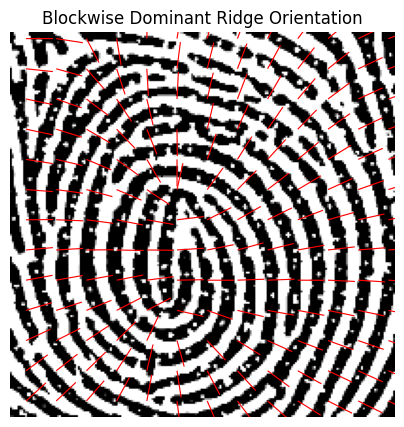

In [168]:
# quiver_theta(
#     theta_smoothed,
#     img=img,
#     stride=16,
#     scale=0.07,
#     width=0.003,
#     color="red",
#     highlight_blocks=True,
# )

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")

stride = w  # Stride is the same as the block size
ys, xs = np.indices(theta_smoothed.shape) * stride + stride // 2
U = np.cos(theta_smoothed) 
V = np.sin(theta_smoothed) 

plt.quiver(
    xs,
    ys,
    U,
    V,
    color="red",
    angles="xy",
    scale_units="xy",
    scale=0.07,
    width=0.003,
    headaxislength=0,
    headlength=0,
    headwidth=0,
)

plt.gca().invert_yaxis()
plt.title("Blockwise Dominant Ridge Orientation")
plt.axis("off")
# plt.show()

In [154]:
# Use the ContinuousFilterLayer to synthesize a fingerprint from theta and freq maps
import torch
import sys

sys.path.append("..")  # go up one directory so Python sees dir2

from utils.torch_filter_module import ContinuousFilterLayer
from utils.filters import seed_pos

# Prepare image scaled to 0..100 like the other pipeline expects
fprint = np.zeros_like(img, dtype=np.float32)
# Create a mask for black areas (value 0) in the original image
black_mask = (img == 0)

# Count total black pixels
total_black_pixels = np.sum(black_mask)

# Calculate seed density based on desired number of seeds
# You can adjust this parameter to control seed amount
desired_seed_density = 0.01

# Calculate number of seeds to place
num_seeds = int(total_black_pixels * desired_seed_density)

# Get coordinates of all black pixels
black_coords = np.argwhere(black_mask)

if len(black_coords) > 0 and num_seeds > 0:
    # Randomly select coordinates from black pixels
    selected_indices = np.random.choice(len(black_coords), 
                                       size=min(num_seeds, len(black_coords)), 
                                       replace=False)
    selected_coords = black_coords[selected_indices]
    
    # Place seeds at selected coordinates
    for coord in selected_coords:
        y, x = coord
        # Place a 4x4 seed block (similar to original seed_pos function)
        y_end = min(y + 4, fprint.shape[0])
        x_end = min(x + 4, fprint.shape[1])
        fprint[y:y_end, x:x_end] = 100
# seed_pos(fprint, img.shape[0], img.shape[1], 0, 500)

0.1 0.1 0.10000000000000003
3.1414796111569694 0.0001365591081574916 1.4807389409571208
torch.Size([41616])
torch.Size([41616])
torch.Size([41616])


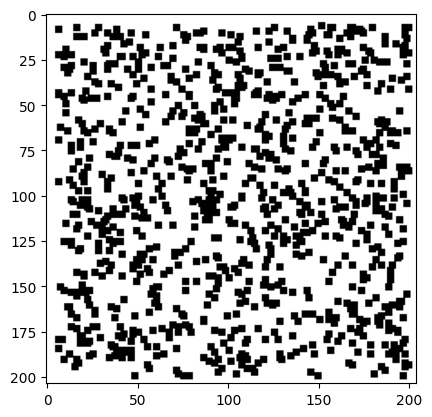

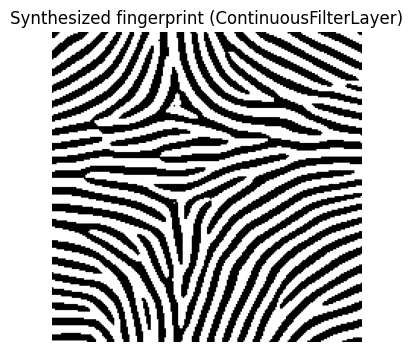

In [ ]:
constant_density = np.full_like(img, 0.10, dtype=float)
def seed_centers_from_mask(seed_img):
    """Return array of (row, col) seed top-left centers from seeded image.

    Seeds are 4x4 blocks set to 100; we detect the top-left pixel of each block
    by selecting mask pixels whose above and left neighbors are False.
    """
    mask = seed_img == 100
    if not np.any(mask):
        return np.zeros((0, 2), dtype=int)
    up = np.roll(mask, 1, axis=0)
    left = np.roll(mask, 1, axis=1)
    up[0, :] = False
    left[:, 0] = False
    top_left = mask & (~up) & (~left)
    pts = np.argwhere(top_left)
    return pts


def to_display(img):
    """Convert fingerprint matrix values (0..100) to 8-bit grayscale image for plotting."""
    return np.clip((1 - img / 100.0) * 255, 0, 255).astype(np.uint8)


# Ensure we have per-pixel orientation and frequency maps at image resolution
C = np.cos(2.0 * theta_smoothed)
S = np.sin(2.0 * theta_smoothed)

# 2) If you need to resize to (H,W), do it on C,S (NOT on angles)
if theta_smoothed.shape != img.shape:
    C = cv2.resize(C, (W, H), interpolation=cv2.INTER_CUBIC)
    S = cv2.resize(S, (W, H), interpolation=cv2.INTER_CUBIC)

# 3) Back to angle, then wrap to [0, π)
theta = 0.5 * np.arctan2(S, C)  # now in (-π/2, π/2]
orient_map = np.mod(theta, np.pi)  # -> [0, π)

freq_map = constant_density.copy()
if freq_map.shape != img.shape:
    freq_map = cv2.resize(freq_map, (W, H), interpolation=cv2.INTER_CUBIC)

print(freq_map.max(), freq_map.min(), freq_map.mean())
print(orient_map.max(), orient_map.min(), orient_map.mean())

# freq_map = np.clip(freq_map * 100, 0, 99).astype(np.float32)

plt.imshow(to_display(fprint), cmap="gray")

# Convert to torch tensors on CPU (will run on CPU by default)
img_t = torch.as_tensor(fprint, dtype=torch.float32)
orient_t = torch.as_tensor(orient_map.astype(np.float32), dtype=torch.float32)
freq_t = torch.as_tensor(freq_map, dtype=torch.float32)

# Instantiate the filter layer; pick a kernel size (odd). 31 is reasonable for 16px blocks.
flayer = ContinuousFilterLayer(
    51, soft_binarize=False, binarization_threshold=52.0, temperature=20.0
)

out_t = img_t
for i in range(3):
    with torch.no_grad():
        out_t = flayer(img=out_t, orient_ind=orient_t + np.pi/2, freq_map=freq_t)

out = out_t.cpu().numpy()

plt.figure(figsize=(4, 5))
plt.imshow(to_display(out), cmap="gray")
plt.title("Synthesized fingerprint (ContinuousFilterLayer)")
plt.axis("off")
plt.show()

## derive phase-field

inspired by this paper right here: https://biometrics.cse.msu.edu/Publications/Fingerprint/FengJain_FpReconstruct_PAMI10.pdf

In [156]:
vx = 2.0*np.pi * freq_map * np.cos(theta)
vy = 2.0*np.pi * freq_map * np.sin(theta)

# central-diff divergence (periodic)
dvx_dx = 0.5*(np.roll(vx, -1, 1) - np.roll(vx,  1, 1))
dvy_dy = 0.5*(np.roll(vy, -1, 0) - np.roll(vy,  1, 0))
div_v  = dvx_dx + dvy_dy

# solve Δψ = div_v in Fourier domain
kx = 2*np.pi*np.fft.fftfreq(W)   # rad/sample
ky = 2*np.pi*np.fft.fftfreq(H)
KX, KY = np.meshgrid(kx, ky)
denom = -(KX**2 + KY**2)

DIV = np.fft.fft2(div_v)
denom[0,0] = 1.0   # avoid divide-by-zero at DC
PSI = DIV / denom
PSI[0,0] = 0.0     # fix arbitrary constant → mean(psi)=0

psi = np.real(np.fft.ifft2(PSI))

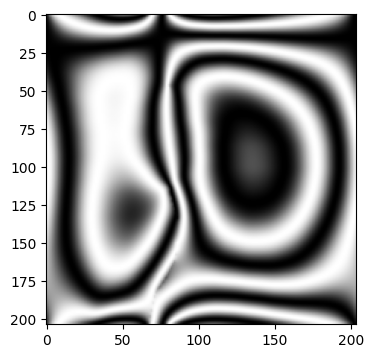

In [157]:
I = 0.5*(1.0 + np.cos(psi))   # in [0,1]
phase_field = (I*255).astype(np.uint8)

plt.figure(figsize=(4, 5))
plt.imshow(phase_field, cmap="gray")

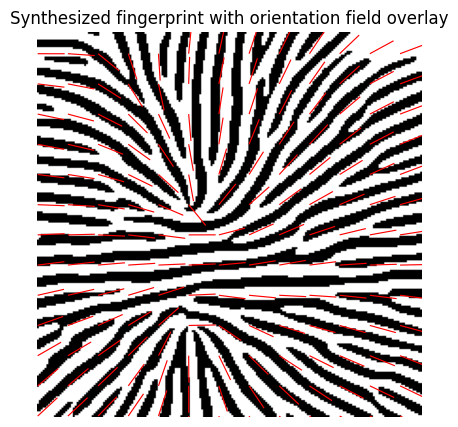

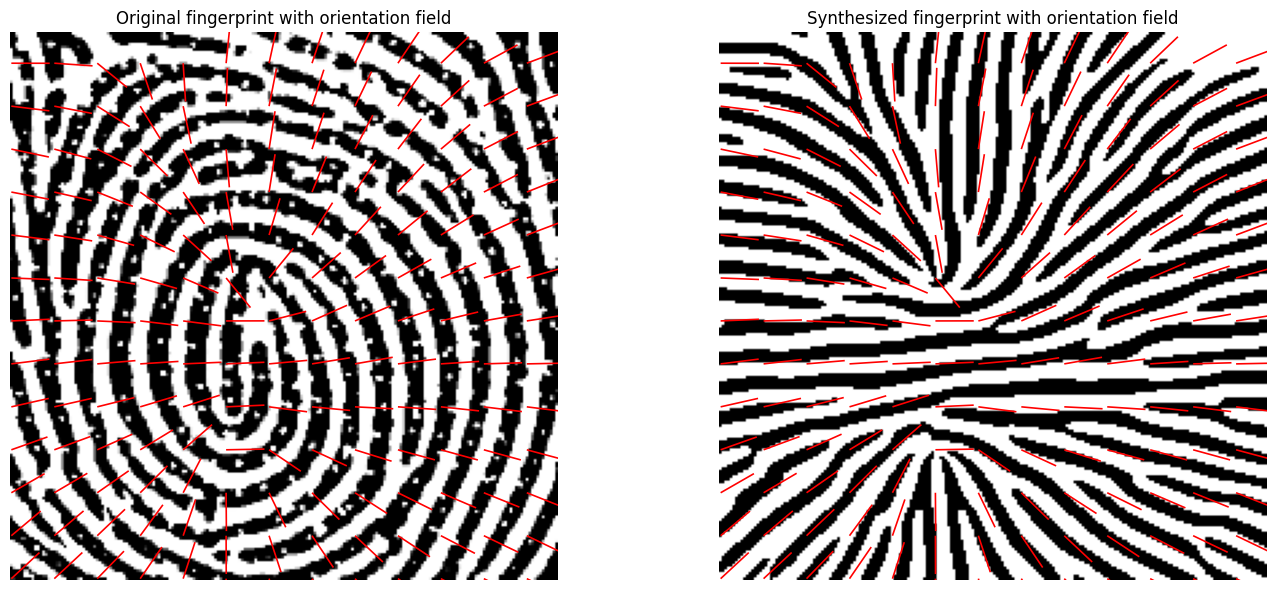

In [158]:
# Plot quiver arrows on the synthesized fingerprint to verify orientation field
plt.figure(figsize=(6, 5))
plt.imshow(to_display(out), cmap='gray')

# Use the same dense orientation field that was used for synthesis
stride = 16  # plot every 16th pixel for readability
ys, xs = np.mgrid[0:H:stride, 0:W:stride]
U = np.cos(theta[::stride, ::stride])
V = np.sin(theta[::stride, ::stride])

plt.quiver(
    xs,
    ys,
    U,
    V,
    color="red",
    angles="xy",
    scale_units="xy",
    scale=0.07,
    width=0.003,
    headaxislength=0,
    headlength=0,
    headwidth=0,
)
plt.gca().invert_yaxis()
plt.title("Synthesized fingerprint with orientation field overlay")
plt.axis("off")
plt.show()

# Create a side-by-side comparison
plt.figure(figsize=(15, 6))

# Original fingerprint with orientation field
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.quiver(
    xs,
    ys,
    U,
    V,
    color="red",
    angles="xy",
    scale_units="xy",
    scale=0.07,
    width=0.003,
    headaxislength=0,
    headlength=0,
    headwidth=0,
)
plt.gca().invert_yaxis()
plt.title("Original fingerprint with orientation field")
plt.axis("off")

# Synthesized fingerprint with orientation field (already plotted above)
plt.subplot(1, 2, 2)
plt.imshow(to_display(out), cmap='gray')
plt.quiver(
    xs,
    ys,
    U,
    V,
    color="red",
    angles="xy",
    scale_units="xy",
    scale=0.07,
    width=0.003,
    headaxislength=0,
    headlength=0,
    headwidth=0,
)
plt.gca().invert_yaxis()
plt.title("Synthesized fingerprint with orientation field")
plt.axis("off")

plt.tight_layout()
plt.show()

## Filtering the original image

torch.Size([41616])


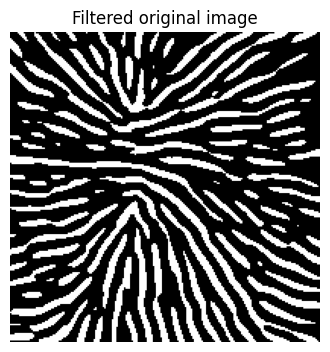

In [159]:
image_tensor = torch.as_tensor(img, dtype=torch.float32)
img_t = image_tensor

for i in range(1):
    with torch.no_grad():
        img_t = flayer(img=img_t, orient_ind=2*torch.pi - orient_t, freq_map=freq_t)

plt.figure(figsize=(4, 5))
plt.imshow(img_t, cmap="gray")
plt.title("Filtered original image")
plt.axis("off")
plt.show()

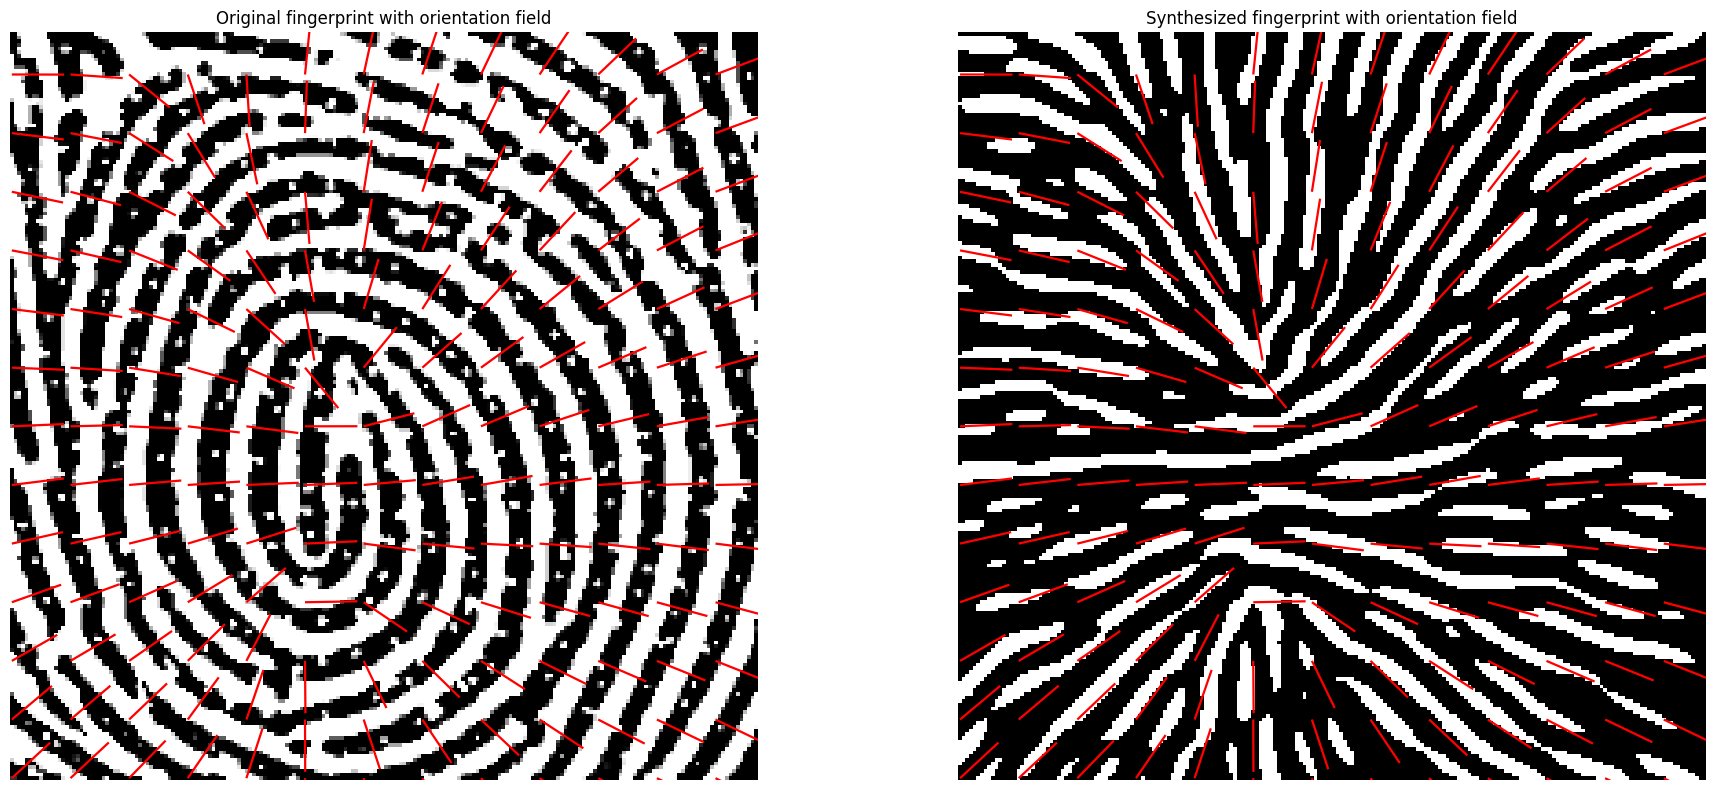

In [160]:
# Use the same dense orientation field that was used for synthesis
stride = 16  # plot every 16th pixel for readability
ys, xs = np.mgrid[0:H:stride, 0:W:stride]
U = np.cos(theta[::stride, ::stride])
V = np.sin(theta[::stride, ::stride])

# Create a side-by-side comparison
plt.figure(figsize=(20, 8))

# Original fingerprint with orientation field
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.quiver(
    xs,
    ys,
    U,
    V,
    color="red",
    angles="xy",
    scale_units="xy",
    scale=0.07,
    width=0.003,
    headaxislength=0,
    headlength=0,
    headwidth=0,
)
plt.gca().invert_yaxis()
plt.title("Original fingerprint with orientation field")
plt.axis("off")

# Synthesized fingerprint with orientation field (already plotted above)
plt.subplot(1, 2, 2)
plt.imshow(img_t, cmap="gray")
plt.quiver(
    xs,
    ys,
    U,
    V,
    color="red",
    angles="xy",
    scale_units="xy",
    scale=0.07,
    width=0.003,
    headaxislength=0,
    headlength=0,
    headwidth=0,
)
plt.gca().invert_yaxis()
plt.title("Synthesized fingerprint with orientation field")
plt.axis("off")

plt.tight_layout()
plt.show()

f_map shape: (13, 13)


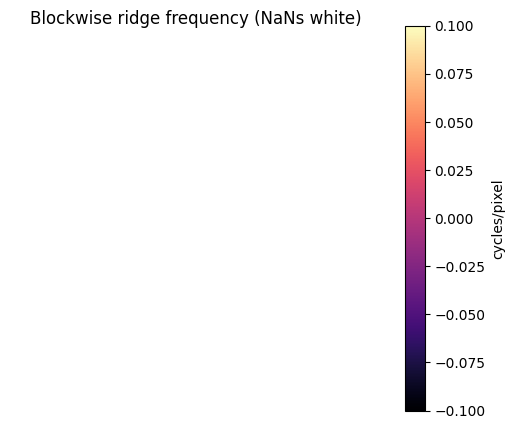

In [161]:
lambda_min = 15.0
lambda_max = 24.0

lower_f = 1.0 / lambda_max
upper_f = 1.0 / lambda_min

min_peak_ratio = 2.0

nb_y, nb_x = theta_smoothed.shape
f_map = np.full((nb_y, nb_x), np.nan)

for by in range(nb_y):
    for bx in range(nb_x):
        # 16x16 block
        y0, x0 = by * w, bx * w
        y1, x1 = min(y0 + w, H), min(x0 + w, W)
        patch = img[y0:y1, x0:x1]

        th = float(theta_smoothed[by, bx])
        M = cv2.getRotationMatrix2D(
            ((x1 - x0) / 2.0, (y1 - y0) / 2.0), -np.rad2deg(th + np.pi/2), 1.0
        )
        rot = cv2.warpAffine(
            patch,
            M,
            (x1 - x0, y1 - y0),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT,
        )

        # 1D profile perpendicular to ridges: average along x (columns)
        prof = rot.mean(axis=1)

        # detrend & normalize
        y = prof - np.mean(prof)
        s = np.std(y) + 1e-8
        y = y / s

        L = len(y)
        Y = np.fft.rfft(y)
        mag = np.abs(Y)
        freqs = np.fft.rfftfreq(L, d=1.0)

        # band-pass: ignore DC and out-of-band
        band = (freqs >= lower_f) & (freqs <= upper_f)
        if band.sum() == 0:
            continue
        band[0] = False  # exclude DC if included

        mag_band = mag[band]
        freqs_band = freqs[band]
        if mag_band.size == 0:
            continue

        k = np.argmax(mag_band)
        dominant_f = float(freqs_band[k])
        med = np.median(mag_band) + 1e-12

        mag_band = mag[band]
        freqs_band = freqs[band]
        if mag_band.size == 0:
            continue

        k = np.argmax(mag_band)
        dominant_f = float(freqs_band[k])
        med = np.median(mag_band) + 1e-12

        if (dominant_f > 0) and ((mag_band[k] / med) >= min_peak_ratio):
            f_map[by, bx] = dominant_f  # cycles/pixel


        peak_f = None
        if mag_band.size > 0:
            k = np.argmax(mag_band)
            med = np.median(mag_band) + 1e-12
            if (mag_band[k] / med) >= min_peak_ratio:
                peak_f = float(freqs_band[k])

        cx, cy = (x1 - x0) / 2.0, (y1 - y0) / 2.0
        dx, dy = np.cos(th), np.sin(th)  # ridge direction (π-periodic arrow is fine)


print("f_map shape:", f_map.shape)

plt.figure(figsize=(6, 5))
plt.title("Blockwise ridge frequency (NaNs white)")
plt.imshow(f_map, cmap="magma")
plt.colorbar(label="cycles/pixel")
plt.axis("off")
plt.show()

filled_freq_map shape: (13, 13)


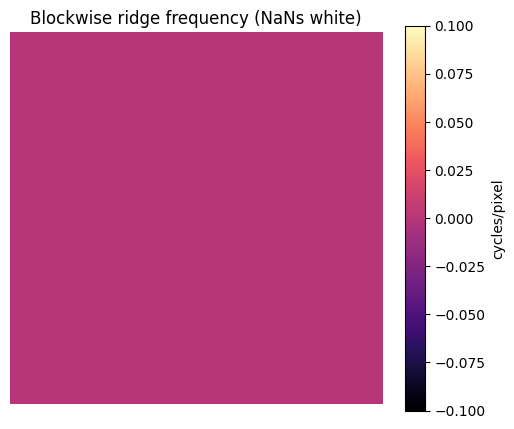

In [162]:
# perform interpolation
om = f_map.copy().astype(np.float64)
om[~np.isfinite(om)] = -1.0  # treat NaNs as invalid too

wOmega = 7
sigma = 9

ax = np.arange(-(wOmega // 2), (wOmega // 2) + 1)
xx, yy = np.meshgrid(ax, ax)
fill_gaussian = np.exp(-(xx**2 + yy**2) / (2 * sigma**2)).astype(np.float64)

max_iters = 50
eps = 1e-12

for it in range(max_iters):
    valid = (om > 0).astype(np.float64)  # δ(x)
    mu = np.where(om > 0, om, 0.0)  # μ(x)

    # numerator: ΣΣ fill_gaussian(u,v) * μ(Ω(i-u, j-v))
    num = cv2.filter2D(mu, ddepth=-1, kernel=fill_gaussian, borderType=cv2.BORDER_REFLECT)

    # denominator: ΣΣ fill_gaussian(u,v) * δ(Ω(i-u, j-v))
    den = cv2.filter2D(valid, ddepth=-1, kernel=fill_gaussian, borderType=cv2.BORDER_REFLECT)

    # Ω' := keep valid as-is; for invalid, use num/den
    om_prime = om.copy()
    fill = num / (den + eps)
    om_prime[om <= 0] = fill[om <= 0]

    # Step (ii): if any -1 remain, swap Ω and Ω' and repeat
    om = om_prime

    # stop if everything is now valid (>0)
    if np.all(om > 0):
        break

# Result: om is the inpainted/smoothed blockwise frequency map (cycles/pixel)
filled_freq_map = om


print("filled_freq_map shape:", filled_freq_map.shape)

plt.figure(figsize=(6, 5))
plt.title("Blockwise ridge frequency (NaNs white)")
plt.imshow(filled_freq_map, cmap="magma")
plt.colorbar(label="cycles/pixel")
plt.axis("off")
plt.show()

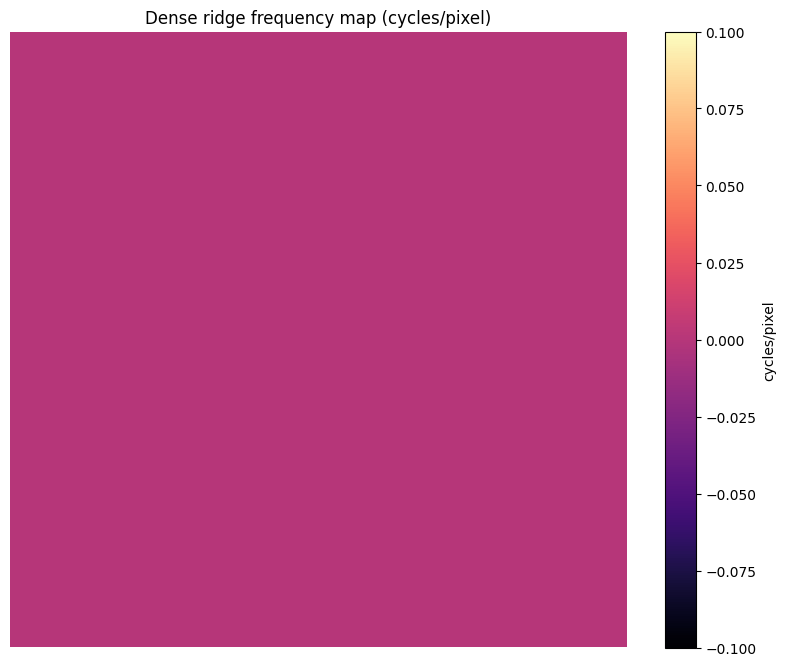

In [163]:
freq_map_smoothed = cv2.GaussianBlur(filled_freq_map, (7, 7), 0)
freq_map_dense = cv2.resize(freq_map_smoothed, (W, H), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(10, 8))
plt.title("Dense ridge frequency map (cycles/pixel)")
plt.imshow(freq_map_dense, cmap="magma")
plt.colorbar(label="cycles/pixel")
plt.axis("off")
plt.show()

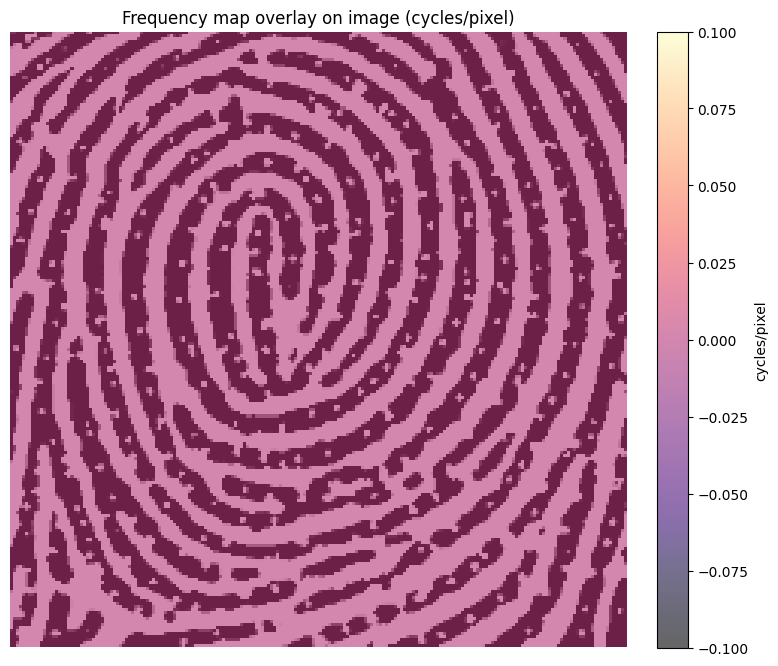

In [164]:
# Overlay the dense frequency map on the original image
plt.figure(figsize=(10, 8))
plt.imshow(img, cmap="gray")
# overlay with some transparency so both image and map are visible
im = plt.imshow(freq_map_dense, cmap="magma", alpha=0.6)
plt.title("Frequency map overlay on image (cycles/pixel)")
plt.axis("off")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("cycles/pixel")
plt.show()

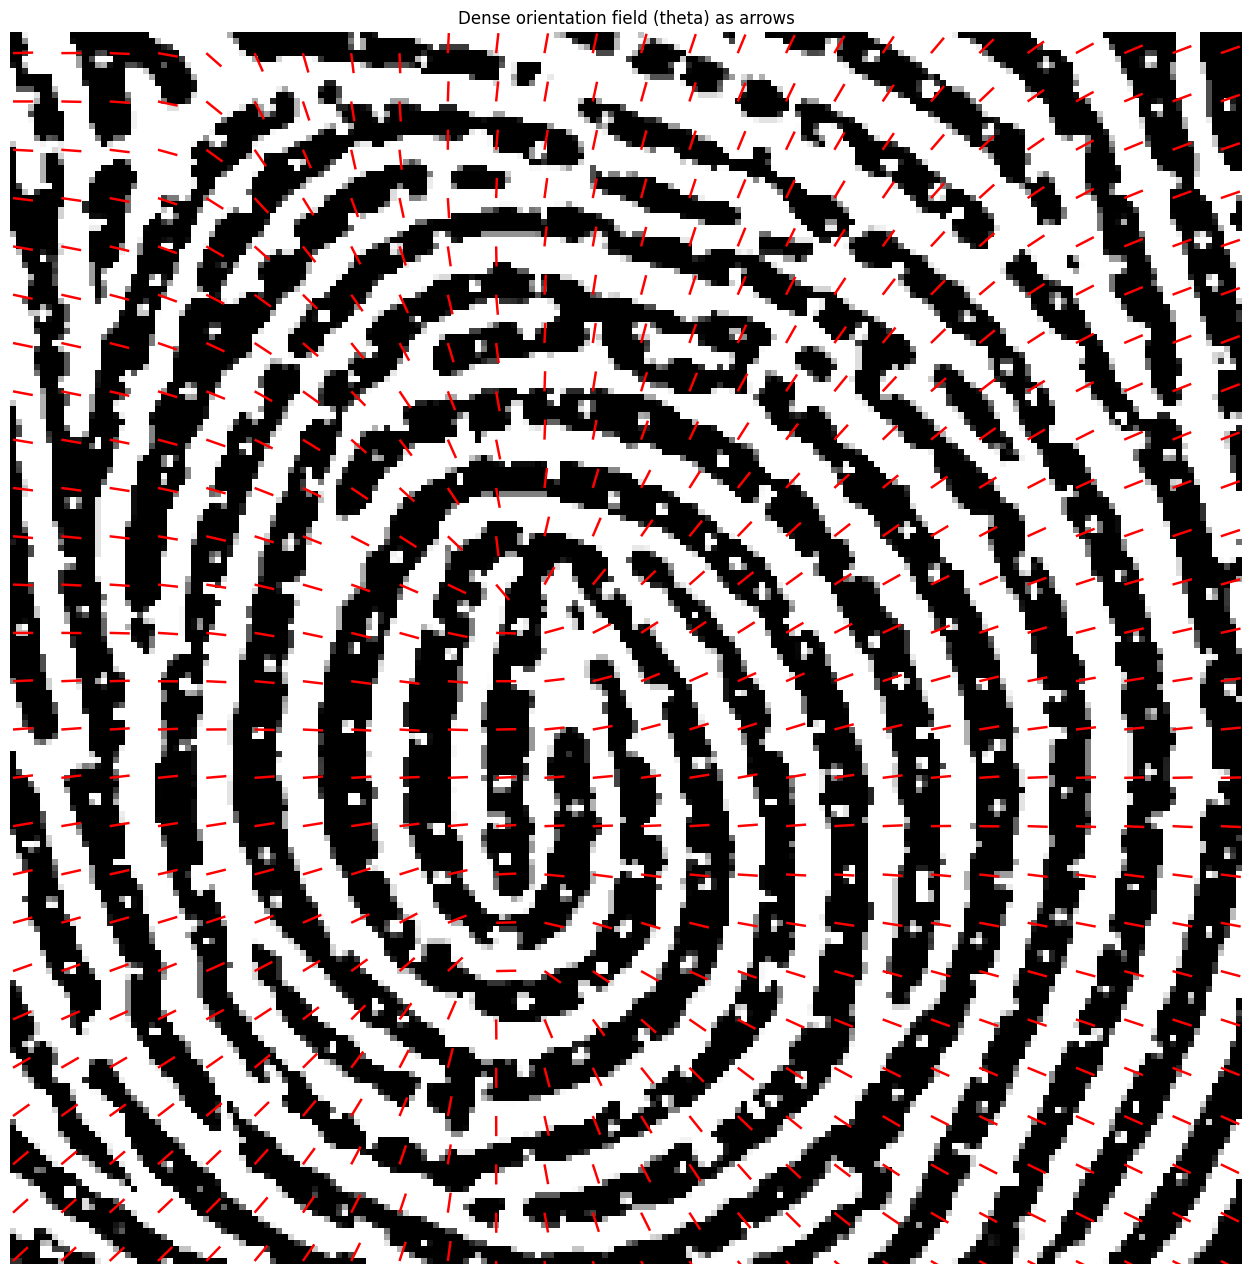

In [165]:
nb_y, nb_x = theta_smoothed.shape
Ux_blk = np.cos(2.0*theta_smoothed)
Uy_blk = np.sin(2.0*theta_smoothed)

# Upsample block vectors to image resolution
Ux = cv2.resize(Ux_blk, (W, H), interpolation=cv2.INTER_CUBIC)
Uy = cv2.resize(Uy_blk, (W, H), interpolation=cv2.INTER_CUBIC)

Ux = cv2.GaussianBlur(Ux, (5, 5), 0)
Uy = cv2.GaussianBlur(Uy, (5, 5), 0)    

# Renormalize to unit circle (avoid 0/0)
mag = np.hypot(Ux, Uy) + 1e-8
Ux /= mag
Uy /= mag

# Back to angle
theta = 0.5 * np.arctan2(Uy, Ux)
plt.figure(figsize=(16, 16))
plt.imshow(img, cmap="gray")
stride = 8  # plot every 8th pixel for readability
ys, xs = np.mgrid[0:H:stride, 0:W:stride]
U = np.cos(theta[::stride, ::stride])
V = np.sin(theta[::stride, ::stride])
plt.quiver(
    xs,
    ys,
    U,
    V,
    color="red",
    angles="xy",
    scale_units="xy",
    scale=0.3,
    width=0.002,
    headaxislength=0,
    headlength=0,
    headwidth=0,
)
plt.gca().invert_yaxis()
plt.title("Dense orientation field (theta) as arrows")
plt.axis("off")
plt.show()

C:\Users\leanh\AppData\Local\Temp\ipykernel_8476\1149494713.py:20: RuntimeWarning: invalid value encountered in divide
  freq_map = ((freq_map - min_val) / (max_val - min_val) * 99).astype(np.float32)


number of seeds in image: 1000
torch.Size([41616])
torch.Size([41616])


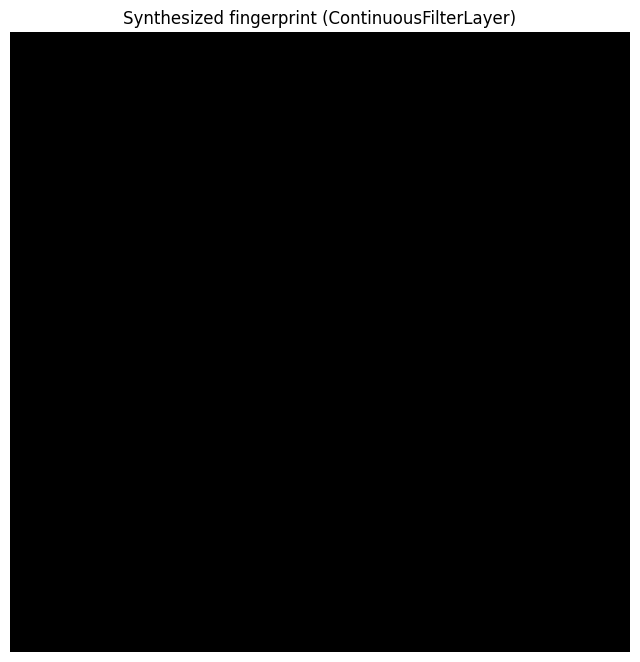

In [166]:
# Use the ContinuousFilterLayer to synthesize a fingerprint from theta and freq maps
import torch
import sys
sys.path.append("..")  # go up one directory so Python sees dir2

from utils.torch_filter_module import ContinuousFilterLayer
from utils.filters import seed_pos

# Ensure we have per-pixel orientation and frequency maps at image resolution
orient_map = theta_smoothed.copy()
if orient_map.shape != img.shape:
    orient_map = cv2.resize(orient_map, (W, H), interpolation=cv2.INTER_CUBIC)

freq_map = freq_map_dense.copy()
if freq_map.shape != img.shape:
    freq_map = cv2.resize(freq_map, (W, H), interpolation=cv2.INTER_CUBIC)

freq_map = np.clip(freq_map * 100, 0, 99).astype(np.float32)
min_val, max_val = freq_map.min(), freq_map.max()
freq_map = ((freq_map - min_val) / (max_val - min_val) * 99).astype(np.float32)

# Prepare image scaled to 0..100 like the other pipeline expects
fprint = np.zeros_like(img, dtype=np.float32)
seed_pos(fprint, img.shape[0], img.shape[1], 0, 1000)

# Convert to torch tensors on CPU (will run on CPU by default)
img_t = torch.as_tensor(fprint, dtype=torch.float32)
orient_t = torch.as_tensor(orient_map.astype(np.float32), dtype=torch.float32)
freq_t = torch.as_tensor(freq_map, dtype=torch.float32)

# Instantiate the filter layer; pick a kernel size (odd). 31 is reasonable for 16px blocks.
flayer = ContinuousFilterLayer(31, soft_binarize=True, binarization_threshold=55.0, temperature=20.0)

for i in range(2):
    with torch.no_grad():
        out_t = flayer(img_t, torch.pi / 2 + orient_t, freq_t)

out = out_t.cpu().numpy()

# Helper to convert 0..100 -> 8-bit grayscale
def to_display(img):
    return np.clip((1 - img / 100.0) * 255, 0, 255).astype(np.uint8)

plt.figure(figsize=(8, 10))
plt.imshow(to_display(out), cmap='gray')
plt.title('Synthesized fingerprint (ContinuousFilterLayer)')
plt.axis('off')
plt.show()